In [14]:
import csv
import h5py
import json

import matplotlib.pyplot as plt
import numpy as np

In [15]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [16]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [17]:
print_tree(data, max_level=3)

data
- coupling_point_1
- - disordered
- - highest
- - highest_postselection
- coupling_point_2
- - highest
- - highest_postselection
- coupling_point_3
- - disordered
- - highest
- - highest_postselection
- coupling_point_4
- - highest
- - highest_postselection
- - lowest
- coupling_point_5
- - disordered
- - highest
- - highest_postselection
- coupling_point_5_retake
- - disordered
- - highest
- - highest_postselection
- coupling_point_6
- - highest
- - highest_postselection
- coupling_point_6_retake
- - disordered
- - highest
- - highest_postselection
simulation
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing
- - no_dephasing_ramp
- - real
- lowest
- - no_dephasing


In [18]:
eigenstate = 'highest'

eigenstate_base = eigenstate.split('_')[0]

[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]
using eigenstate highest_postselection for coupling_point_1


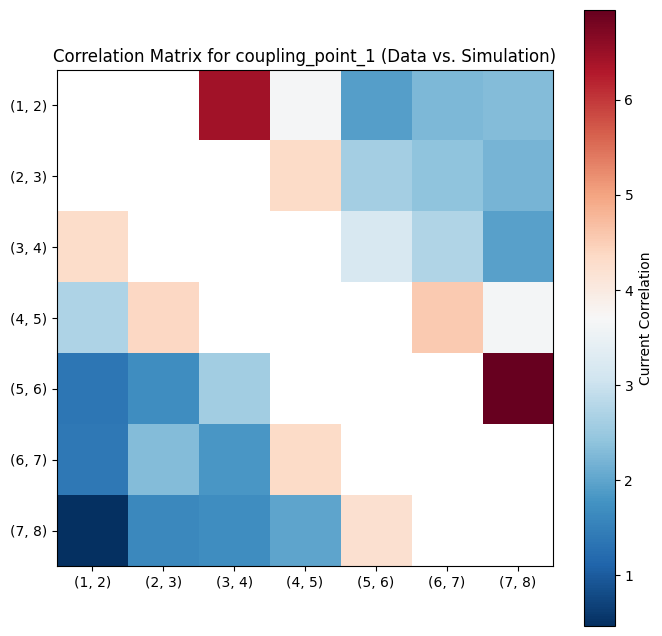

using eigenstate highest_postselection for coupling_point_2


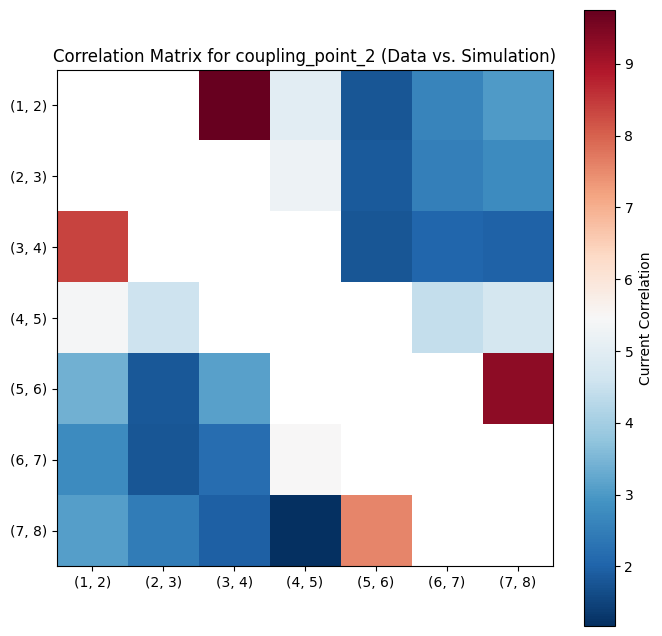

using eigenstate highest_postselection for coupling_point_3


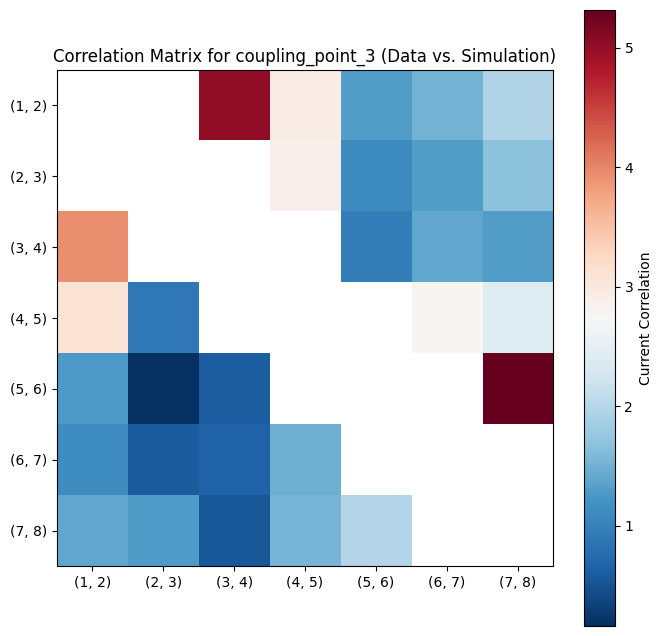

using eigenstate highest_postselection for coupling_point_4


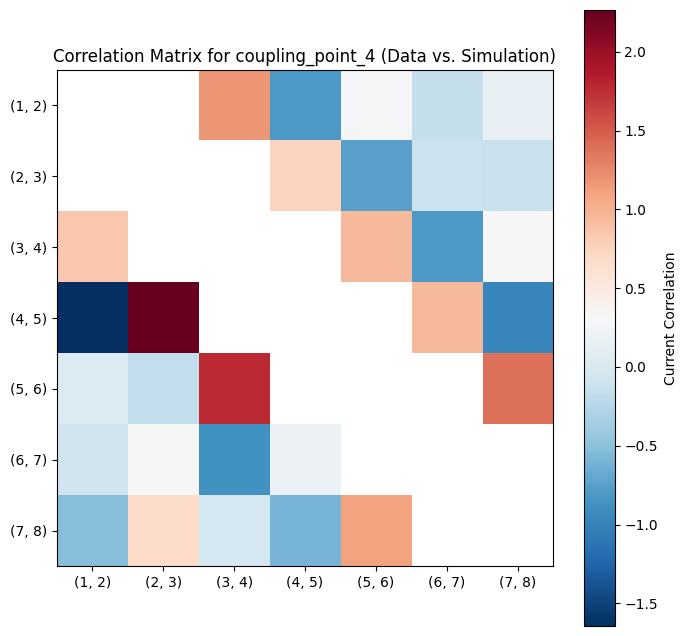

using eigenstate highest_postselection for coupling_point_5


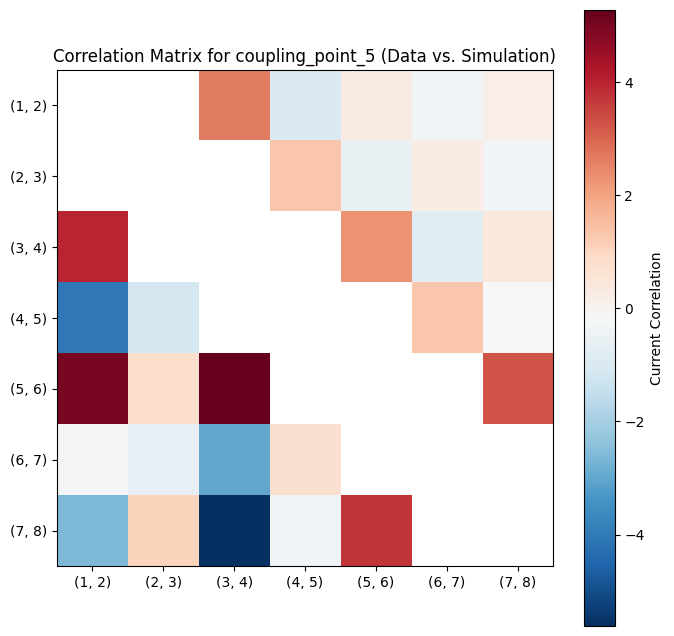

using eigenstate highest_postselection for coupling_point_6


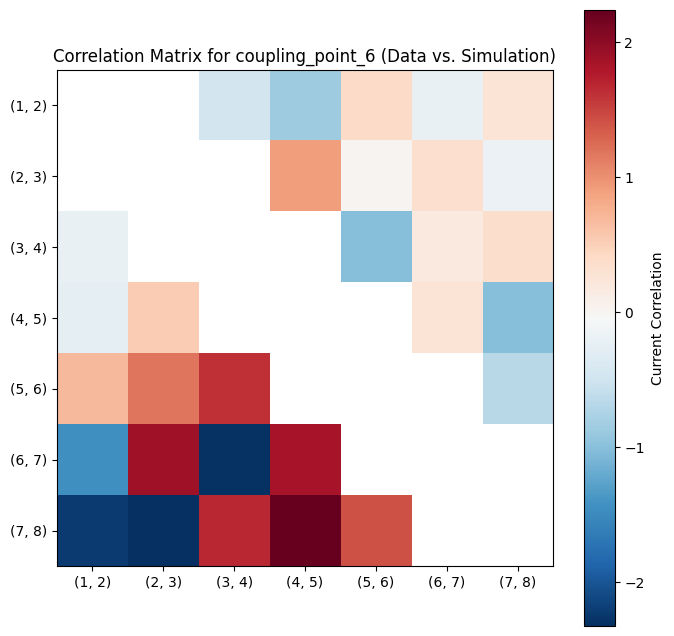

In [19]:
all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# some data is from the retake
all_coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5_retake',
    'coupling_point_6_retake'
]

# current correlation data looks much better from the initial run
all_coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5',
    'coupling_point_6'
]

all_eigenstates = [
    'highest_postselection',
    'highest_postselection',
    'highest_postselection',
    'highest_postselection',
    'highest_postselection',
    'highest_postselection',
]


all_pairs = [(i,i+1) for i in range(1,8)]
print(all_pairs)

dephasing = 'real'

for i in range(len(all_coupling_points)):
    coupling_point = all_coupling_points[i]

    if coupling_point in data['data']:

        eigenstate = all_eigenstates[i]
        eigenstate_base = eigenstate.split('_')[0]

        if eigenstate in data['data'][coupling_point]:
            coupling_point_data = data['data'][coupling_point][eigenstate]
            print(f'using eigenstate {eigenstate} for {coupling_point}')
        elif eigenstate_base in data['data'][coupling_point]:
            coupling_point_data = data['data'][coupling_point][eigenstate_base]
        else:
            print(f'No data for {coupling_point} with eigenstate {eigenstate} or base {eigenstate_base}')
            continue
        coupling_point_sim = data['simulation'][eigenstate_base][dephasing][coupling_point]

        correlation_matrix = np.zeros((len(all_pairs),len(all_pairs)))

        for i in range(len(all_pairs)):
            pair_1 = all_pairs[i]
            for j in range(i, len(all_pairs)):
                pair_2 = all_pairs[j]
                if set(pair_1).intersection(set(pair_2)):
                    correlation_matrix[i, j] = np.nan
                    correlation_matrix[j, i] = np.nan
                else:
                    correlation_data = coupling_point_data[str((pair_1, pair_2))]['current_correlation_value']
                    correlation_sim_BS = coupling_point_sim[str((pair_1, pair_2))]['current_correlation_BS_value']

                    correlation_matrix[j, i] = correlation_data
                    correlation_matrix[i, j] = correlation_sim_BS
    else:
        # for coupling points with no data, fill with randoms for now
        correlation_matrix = np.random.rand(len(all_pairs), len(all_pairs))

    fig, ax = plt.subplots(figsize=(8,8))
    im = ax.imshow(correlation_matrix, cmap='RdBu_r')
    ax.set_xticks(np.arange(len(all_pairs)))
    ax.set_xticklabels(all_pairs)
    ax.set_yticks(np.arange(len(all_pairs)))
    ax.set_yticklabels(all_pairs)
    fig.colorbar(im, ax=ax, label='Current Correlation')
    
    plt.title(f'Correlation Matrix for {coupling_point} (Data vs. Simulation)')
    plt.show()

    # default is highest eigenstate and real dephasing
    correlation_matrix_filename = f'plots\\correlation_matrices\\{coupling_point}_correlation_matrix.csv'
    with open(correlation_matrix_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        for i, pair_1 in enumerate(all_pairs):
            row = list(correlation_matrix[i, :])
            writer.writerow(row)
    


In [20]:
for i in range(len(all_coupling_points)):
    coupling_point = all_coupling_points[i]
    eigenstate = all_eigenstates[i]
    if coupling_point in data['data']:
        print()
        print(f'{coupling_point}')
        print()
        # print_tree(data['data'][coupling_point]['highest'], max_level=2)
        print(data['data'][coupling_point][eigenstate]['current_correlation_total'])


coupling_point_1

9.775828253245317

coupling_point_2

10.580432766758474

coupling_point_3

3.313785227276006

coupling_point_4

0.011166922696428938

coupling_point_5

0.050390634622124036

coupling_point_6

0.22408837726148834


In [21]:
# all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# all_pairs = [(i,i+1) for i in range(1,8)]
# print(all_pairs)

# dephasing = 'real'

# for coupling_point in all_coupling_points:

#     if coupling_point in data['data']:

#         coupling_point_data = data['data'][coupling_point]['highest']
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])
#         coupling_point_sim = data['simulation']['highest'][dephasing][coupling_point]

#         print(coupling_point)
#         print(coupling_point_data.keys())

#         distance_to_current_correlation_error = coupling_point_data['distance_to_current_correlation_error']
#         distance_to_current_correlation_value = coupling_point_data['distance_to_current_correlation_value']
        
#         current_correlation_averages = coupling_point_data['current_correlation_averages']
    


In [22]:
### export total chiral currents explicitly

values = []
errors = []
for i in range(len(all_coupling_points)):
    coupling_point = all_coupling_points[i]
    eigenstate = all_eigenstates[i]
    if coupling_point in data['data']:
        coupling_point_data = data['data'][coupling_point][eigenstate]
        value = coupling_point_data['current_correlation_total']

        print(coupling_point_data['current_correlation_averages'])
        print(sum(coupling_point_data['current_correlation_averages']))

        if 'current_correlation_total_readout_std_error' in coupling_point_data:
            error = coupling_point_data['current_correlation_total_readout_std_error']
        else:
            error = 50
    else:
        value = 0
        error = 50
    values.append(value)
    errors.append(error)

print(values)
print(errors)

with open('plots/current_correlation_totals.csv', 'w', newline='\n') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(values)
    writer.writerow(errors)

[3.9605404  2.05659014 1.78394949 1.50668757 0.46806066]
9.775828253245317
[4.11266168 1.47882874 1.69440209 1.41687137 1.87766888]
10.580432766758474
[1.09942117 0.61889978 0.54184714 0.37920114 0.67441599]
3.313785227276006
[ 0.84197703 -0.60413378  0.05114893  0.14861724 -0.4264425 ]
0.011166922696428938
[ 0.70881418 -0.46777279  0.25655893 -0.32037056 -0.12683913]
0.050390634622124036
[ 0.39607327 -0.24426085  0.22419418 -0.41656119  0.26464297]
0.22408837726148834
[9.775828253245317, 10.580432766758474, 3.313785227276006, 0.011166922696428938, 0.050390634622124036, 0.22408837726148834]
[0.1758708794919406, 0.2006934369997259, 0.11141174718176267, 0.21386863284158728, 0.16248358084238437, 0.02352477041941112]


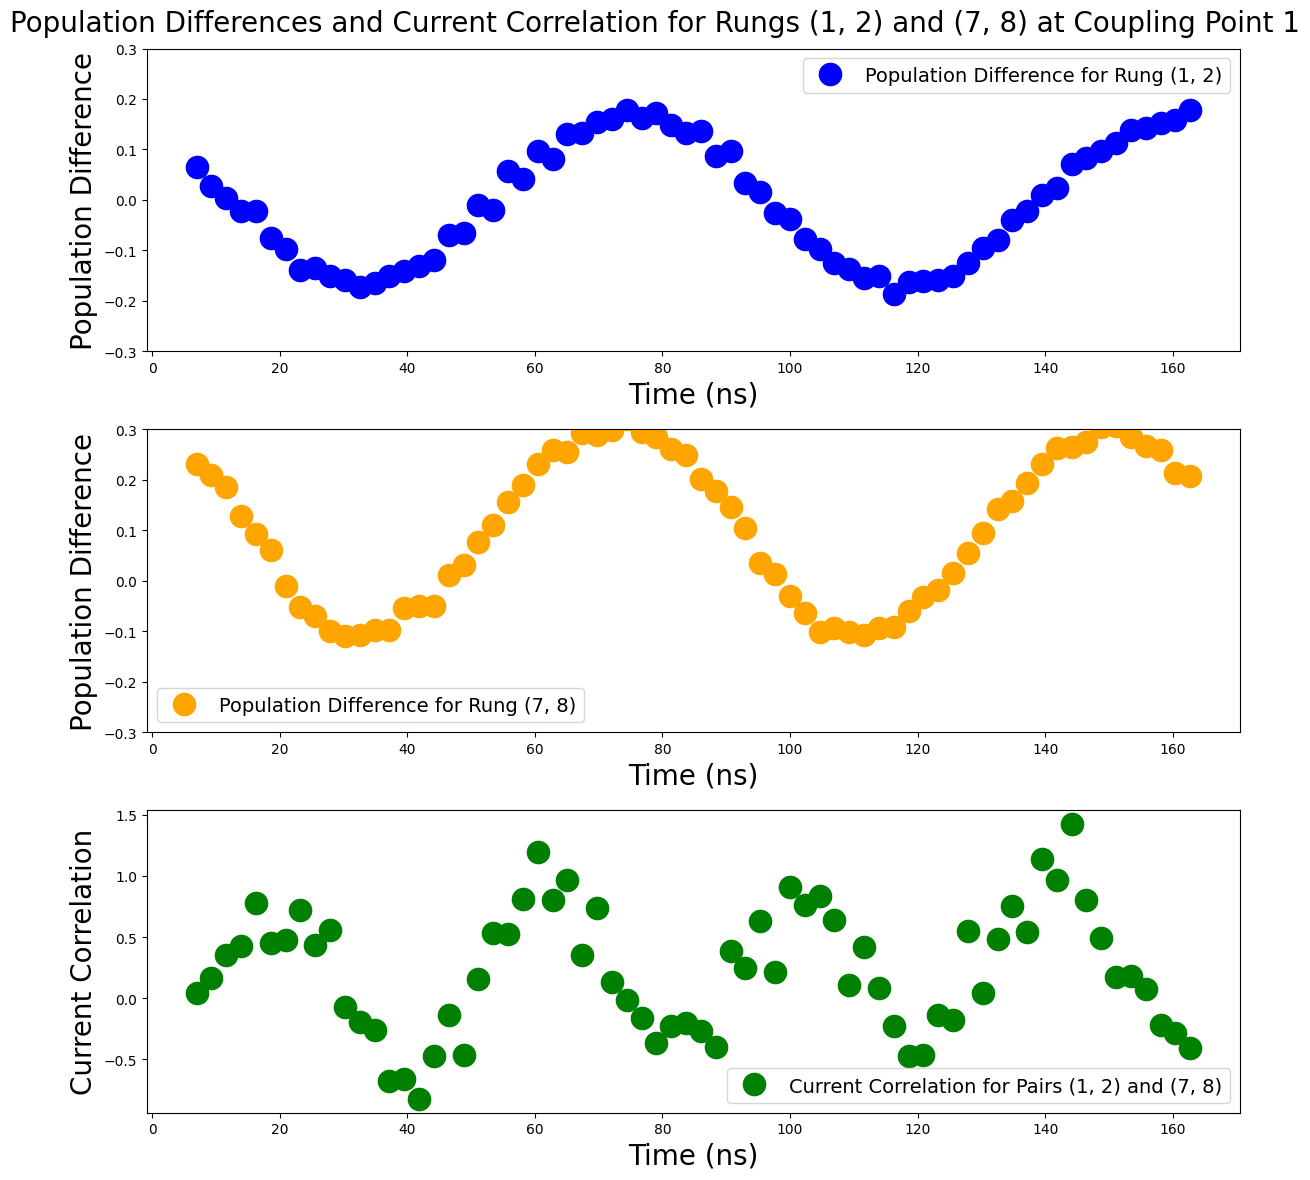

In [23]:
### export two population swaps and one correlations into csv for figure 2

coupling_point = 3
correlation_pair = ((5,6),(7,8)) # this one looks good

coupling_point = 1
correlation_pair = ((1,2),(7,8)) # this one also looks good

start_index = 3

pair_1, pair_2 = correlation_pair

swap_1_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['population_difference'][0,start_index:]
# swap_1_error = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['population_difference_error'][0,start_index:]

swap_2_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['population_difference'][1,start_index:]

correlation_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['current_correlation'][start_index:]

times = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['times'][start_index:]

fig, axes = plt.subplots(3,1, figsize=(12, 12))


fontsize = 20
axes[0].plot(times, swap_1_data, color='blue', linestyle='', marker='o', ms=16, label=f'Population Difference for Rung {pair_1}')
axes[0].set_xlabel('Time (ns)', fontsize=fontsize)
axes[0].set_ylabel('Population Difference', fontsize=fontsize)
axes[0].legend(fontsize=fontsize - 6)
axes[0].set_ylim(-0.3, 0.3)

axes[1].plot(times, swap_2_data, color='orange', linestyle='', marker='o', ms=16, label=f'Population Difference for Rung {pair_2}')
axes[1].set_xlabel('Time (ns)', fontsize=fontsize)
axes[1].set_ylabel('Population Difference', fontsize=fontsize)
axes[1].legend(fontsize=fontsize - 6)
axes[1].set_ylim(-0.3, 0.3)

axes[2].plot(times, correlation_data, color='green', linestyle='', marker='o', ms=16, label=f'Current Correlation for Pairs {pair_1} and {pair_2}')
axes[2].set_xlabel('Time (ns)', fontsize=fontsize)
axes[2].set_ylabel('Current Correlation', fontsize=fontsize)
axes[2].legend(fontsize=fontsize - 6)

plt.suptitle(f'Population Differences and Current Correlation for Rungs {pair_1} and {pair_2} at Coupling Point {coupling_point}', fontsize=fontsize)
plt.tight_layout()
plt.show()


### write to csv

fig_2_filename = f'plots/figure_2_data.csv'

with open(fig_2_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(times)
    writer.writerow(swap_1_data)
    writer.writerow(swap_2_data)
    writer.writerow(correlation_data)

In [24]:
### export data for making presentation figures

correlation_pairs = []
for i in range(len(all_pairs)):
    for j in range(len(all_pairs)):
        if i < j-1:
            correlation_pairs.append((all_pairs[i], all_pairs[j]))

presentation_correlation_data_filename = f'plots/presentation_correlation_data.csv'


coupling_point = 1
correlation_pair = ((1,2),(7,8)) # this one also looks good

start_index = 3

times_1234 = data['data'][f'coupling_point_{coupling_point}']['highest'][str(((1,2),(3,4)))]['times'][start_index:]

with open(presentation_correlation_data_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)

    # alternative option, but would need all time arrays to be identical which isn't the case
    # header = ['Time (ns)'] + [f'{correlation_pair} correlation' for correlation_pair in correlation_pairs]
    # writer.writerow(header)

    for correlation_pair in correlation_pairs:

        correlation_data = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['current_correlation'][start_index:]

        times = data['data'][f'coupling_point_{coupling_point}']['highest'][str(correlation_pair)]['times'][start_index:]

        writer.writerow([correlation_pair] + list(times))
        writer.writerow([correlation_pair] + list(correlation_data))